# Lyapunov Exponent Analysis (Python)
Analysis of pre-run spin chain simulations: loading saved Lyapunov exponent data, averaging, and plotting.

> Did you know you can do this

## Imports & Setup

In [9]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import os

# Some utility functions
def make_path_exist(filepath):
    """Ensure the directory for a given filepath exists."""
    os.makedirs(os.path.dirname(filepath), exist_ok=True)

def save_simple_dict_to_csv(data: dict, filepath: str):
    """Save a {float: float} dict to CSV with columns 'aval' and 'value'."""
    make_path_exist(filepath)
    df = pd.DataFrame(sorted(data.items()), columns=["aval", "value"])
    df.to_csv(filepath, index=False)



def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 40
    plt.rcParams["axes.labelsize"] = 42
    plt.rcParams["legend.fontsize"] = 30

    # plt.rcParams["font.size"] = 18
    # plt.rcParams["axes.labelsize"] = 24
    # plt.rcParams["legend.fontsize"] = 12

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()

## Global Parameters

In [48]:
J   = 1
tau = 1 * J

num_unit_cells_vals = [16, 32, 64, 128]
# num_unit_cells_vals = [64, 128]
# num_unit_cells_vals = [128]
num_uc = len(num_unit_cells_vals)

# Blue palette: light -> dark, one colour per system size
blue_colors = [mcolors.to_rgba(c) for c in
               plt.cm.Blues(np.linspace(0.35, 0.85, num_uc))]

num_initial_conds = 1000

a_vals = [0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.7525, 0.755, 0.7563, 0.7575, 0.7588,
          0.7594, 0.76, 0.7605, 0.761, 0.7615, 0.762, 0.7625, 0.763, 0.765,
          0.7675, 0.77, 0.78, 0.79, 0.8]

# a_vals = [1.0]

epsilon = 0.1
N_val   = 4

z_val      = 1.7
z_val_name = str(z_val).replace(".", "p")
z_fit      = 1.34
z_fit_name = str(z_fit).replace(".", "p")

max_time_prefact = 3
averaging_windows = [1/3]

parent_data_path = "/Volumes/ExternalData"  # <- adjust as needed
local_parent_data_path = "../data"  # <- adjust as needed

In [12]:
os.listdir("../data")

['log_delta_evolved_spins',
 '.DS_Store',
 'spin_chain_lambdas_new',
 'spin_chain_lambdas',
 's_diff_per_time',
 'non_trand',
 '.gitignore',
 's_diffs_tf',
 'delta_evolved_spins',
 '.git',
 'evolved_spins']

## Step 1 — Load Raw Samples, Compute Averages, Save CSVs
Reads per-sample Lyapunov time-series from disk, trims the transient, averages over initial conditions, and writes a summary CSV.

In [47]:
for averaging_window in averaging_windows:
    print(f"Averaging window: {averaging_window}")
    skip_fract = 1 - averaging_window
    aw_name = str(round(averaging_window, 3)).replace(".", "p")

    collected_lambdas_step1     = {}   # {L: {a_val: mean_lambda}}
    collected_lambda_SEMs_step1 = {}   # {L: {a_val: SEM}}

    for num_unit_cells in num_unit_cells_vals:
        L = num_unit_cells * N_val
        print(f"  L = {L}")
        n        = min(int(L**1.7), int(round(max_time_prefact*L ** z_fit)))
        num_skip = int(round(skip_fract * n))

        collected_lambdas_step1[L]     = {a: 0.0 for a in a_vals}
        collected_lambda_SEMs_step1[L] = {a: 0.0 for a in a_vals}

        for a_val in a_vals:
            a_name = str(a_val).replace(".", "p")
            current_lambdas = np.zeros(num_initial_conds)

            init_cond = 1
            j=0
            data_folder = f"{parent_data_path}/spin_dists_per_time_new/N{N_val}/a{a_name}/IC1/L{L}/"
            data_folder_contents = os.listdir(data_folder)
            while init_cond <= num_initial_conds:
                sample_filepath = (
                    f"{parent_data_path}/spin_dists_per_time_new/N{N_val}/a{a_name}/IC1/L{L}/"
                    f"N{N_val}_a{a_name}_IC1_L{L}_z{z_val_name}_sample{init_cond}.csv"
                )
                df_sample = pd.read_csv(sample_filepath, usecols=["lambda"])
                lambda_vec = df_sample["lambda"].values[num_skip:n]
                current_lambdas[init_cond - 1] = lambda_vec.sum() / (len(lambda_vec) * tau)

                init_cond += 1

            collected_lambdas_step1[L][a_val]     = current_lambdas.mean()
            collected_lambda_SEMs_step1[L][a_val] = current_lambdas.std(ddof=1) / np.sqrt(num_initial_conds)

        # Write summary CSV
        a_range_name = f"{min(a_vals)}_{max(a_vals)}".replace(".", "p")
        csv_path = (
            f"{local_parent_data_path}/spin_chain_lambdas_new/N{N_val}/SeveralAs/IC{num_initial_conds}/L{L}/"
            f"N{N_val}_ar{a_range_name}_IC{num_initial_conds}_L{L}_AW{aw_name}_z{z_fit_name}_endpref{max_time_prefact}.csv"
        )
        make_path_exist(csv_path)
        rows = [
            {"aval": a, "lambda": collected_lambdas_step1[L][a],
             "lambda_sem": collected_lambda_SEMs_step1[L][a]}
            for a in sorted(a_vals)
        ]
        pd.DataFrame(rows).to_csv(csv_path, index=False)
        print(f"    Saved: {csv_path}")

Averaging window: 0.3333333333333333
  L = 256
    Saved: ../data/spin_chain_lambdas_new/N4/SeveralAs/IC1000/L256/N4_ar0p7_0p8_IC1000_L256_AW0p333_z1p34_endpref3.csv
  L = 512
    Saved: ../data/spin_chain_lambdas_new/N4/SeveralAs/IC1000/L512/N4_ar0p7_0p8_IC1000_L512_AW0p333_z1p34_endpref3.csv


In [4]:
a_val, sample_filepath

(0.762,
 '/Volumes/ExternalData/spin_dists_per_time_new/N4/a0p762/IC1/L512/N4_a0p762_IC1_L512_z1p7_sample502.csv')

## Step 2 — Load Summary CSVs into Memory

In [49]:
# collected_lambdas[aw][L][a_val]      = mean lambda
# collected_lambdas_SEMs[aw][L][a_val] = SEM
collected_lambdas     = {}
collected_lambdas_SEMs = {}

for averaging_window in averaging_windows:
    print(f"Loading AW = {averaging_window}")
    aw_name = str(round(averaging_window, 3)).replace(".", "p")
    cur_lam  = {}
    cur_sems = {}

    for num_unit_cells in num_unit_cells_vals:
        L = num_unit_cells * N_val
        a_range_name = f"{min(a_vals)}_{max(a_vals)}".replace(".", "p")
        csv_path = (
            f"{local_parent_data_path}/spin_chain_lambdas_new/N{N_val}/SeveralAs/IC{num_initial_conds}/L{L}/"
            f"N{N_val}_ar{a_range_name}_IC{num_initial_conds}_L{L}_AW{aw_name}_z{z_fit_name}_endpref{max_time_prefact}.csv"
        )
        df = pd.read_csv(csv_path)
        cur_lam[L]  = dict(zip(df["aval"], df["lambda"]))
        cur_sems[L] = dict(zip(df["aval"], df["lambda_sem"]))

    collected_lambdas[averaging_window]      = cur_lam
    collected_lambdas_SEMs[averaging_window] = cur_sems

print("Done loading.")

Loading AW = 0.3333333333333333
Done loading.


In [23]:
0.444497392526067 - 3.394623373259752e-05

0.4444634462923344

In [6]:
collected_lambdas, collected_lambdas_SEMs

({0.5: {512: {1.0: 0.444497392526067}}},
 {0.5: {512: {1.0: 3.394623373259752e-05}}})

## Step 3 — Save Variance Data for Collapse Analysis

In [89]:
collapse_a_vals = [a for a in a_vals]

for averaging_window in averaging_windows:
    aw_name = str(round(averaging_window, 3)).replace(".", "p")
    for num_unit_cells in num_unit_cells_vals:
        L = num_unit_cells * N_val
        data = {
            a: collected_lambdas_SEMs[averaging_window][L][a] * np.sqrt(num_initial_conds - 1)
            for a in collapse_a_vals
        }
        a_range_name = f"{min(collapse_a_vals)}_{max(collapse_a_vals)}".replace(".", "p")
        filepath = (
            f"../data_to_collapse/lambda_var_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
            f"lambda_var_per_a_N{N_val}_ar{a_range_name}_IC{num_initial_conds}_L{L}_z{z_fit_name}_AW{aw_name}.csv"
        )
        print(f"Saved: {filepath}")
        save_simple_dict_to_csv(data, filepath)

print("Variance data saved.")

Saved: ../data_to_collapse/lambda_var_per_a/N4/SeveralAs/IC1000/SeveralLs/lambda_var_per_a_N4_ar0p7_0p8_IC1000_L64_z1p34_AW0p625.csv
Saved: ../data_to_collapse/lambda_var_per_a/N4/SeveralAs/IC1000/SeveralLs/lambda_var_per_a_N4_ar0p7_0p8_IC1000_L128_z1p34_AW0p625.csv
Saved: ../data_to_collapse/lambda_var_per_a/N4/SeveralAs/IC1000/SeveralLs/lambda_var_per_a_N4_ar0p7_0p8_IC1000_L256_z1p34_AW0p625.csv
Saved: ../data_to_collapse/lambda_var_per_a/N4/SeveralAs/IC1000/SeveralLs/lambda_var_per_a_N4_ar0p7_0p8_IC1000_L512_z1p34_AW0p625.csv
Variance data saved.


## Plot 1 — λ vs *a* (Main Result)

Saved: figs/lambda_per_a/N4/SeveralAs/IC1000/SeveralLs/lambda_per_a_N4_AW0p5_z1p34.png


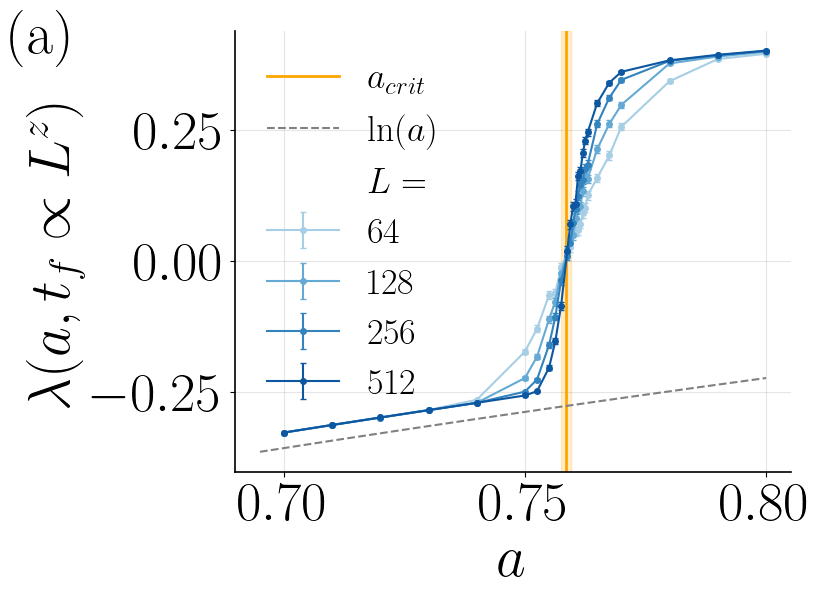

In [72]:
a_crit, a_crit_err = 0.7585, 0.001
for averaging_window in averaging_windows:
    aw_name = str(round(averaging_window, 3)).replace(".", "p")

    fig, ax = plt.subplots(figsize=(9, 7))
    # ax.set_xlim(0.695, 0.8025)
    # ax.text(-0.19, 1.01, "(a)", transform=ax.transAxes, fontsize=20, va="top", ha="left")


    x_range = np.linspace(min(a_vals) - 0.005, max(a_vals) + 0.00005, 1000)
    ax.axvspan(a_crit - a_crit_err, a_crit + a_crit_err, color="orange", alpha=0.2)
    ax.axvline(a_crit, color="orange", lw=2, label=r"$a_{crit}$")
    ax.plot(x_range, np.log(x_range), linestyle="--", color="gray", label=r"$\ln(a)$")

    plt.plot([], [], label=r"$L=$", c=(1, 1, 1, 0))

    L_vals = [n * N_val for n in num_unit_cells_vals]
    for i, L in enumerate(L_vals):
        lam_dict = collected_lambdas[averaging_window][L]
        sem_dict = collected_lambdas_SEMs[averaging_window][L]
        xs = sorted(lam_dict.keys())
        ys = [lam_dict[a] for a in xs]
        yerr = [sem_dict[a] for a in xs]
        ax.errorbar(xs, ys, yerr=yerr, marker="o", markersize=4,
                    label=str(L), color=blue_colors[i], capsize=2)


    ax.set_xlabel(r"$a$")
    ax.set_ylabel(rf"$\lambda(a, t_f \propto L^z)$")
    # ax.set_title(rf"$\lambda(t=L^{{{z_fit}}}, a)$ for $N={N_val}$, $AW={averaging_window}$")
    ax.text(0.05, 0.85, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    ax.legend(loc="best",fontsize=plt.rcParams["legend.fontsize"]-4)

    plot_path = (
        f"figs/lambda_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
        f"lambda_per_a_N{N_val}_AW{aw_name}_z{z_fit_name}.png"
    )
    make_path_exist(plot_path)
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150)
    print(f"Saved: {plot_path}")
    plt.show()

Saved: figs/lambda_per_a/N4/SeveralAs/IC1000/SeveralLs/fss_lambda_per_a_N4_AW0p5_z1p34.png


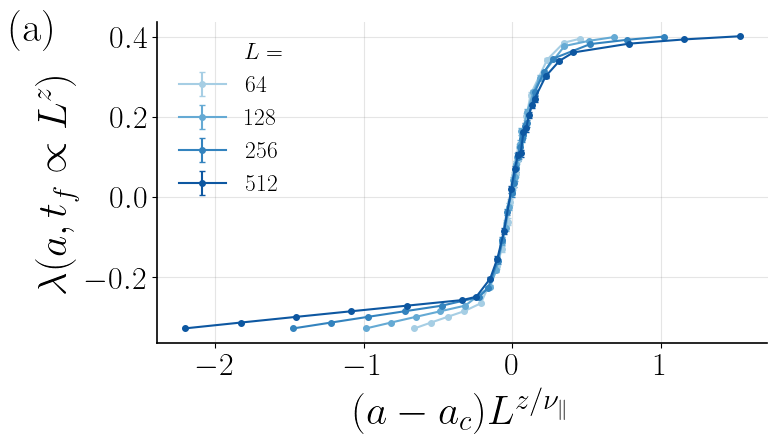

In [ ]:
a_crit, a_crit_err = 0.7585, 0.001
a_crit, a_crit_err = 0.759, 0.0002
nu_par, nu_par_err         = 2.24, 0.05
z_collapse = 1.3
nu = nu_par/z_collapse

for averaging_window in averaging_windows:
    aw_name = str(round(averaging_window, 3)).replace(".", "p")

    fig, ax = plt.subplots(figsize=(8, 5))
    # ax.set_xlim(0.695, 0.8025)
    # ax.text(-0.19, 1.01, "(a)", transform=ax.transAxes, fontsize=20, va="top", ha="left")


    x_range = np.linspace(min(a_vals) - 0.005, max(a_vals) + 0.00005, 1000)
    # ax.axvspan(a_crit - a_crit_err, a_crit + a_crit_err, color="orange", alpha=0.2)
    # ax.axvline(a_crit, color="orange", lw=2, label=r"$a_{crit}$")
    # ax.plot(x_range, np.log(x_range), linestyle="--", color="gray", label=r"$\ln(a)$")

    plt.plot([], [], label=r"$L=$", c=(1, 1, 1, 0))

    L_vals = [n * N_val for n in num_unit_cells_vals]
    for i, L in enumerate(L_vals):
        lam_dict = collected_lambdas[averaging_window][L]
        sem_dict = collected_lambdas_SEMs[averaging_window][L]
        xs = np.array(sorted(lam_dict.keys()))
        ys = [lam_dict[a] for a in xs]
        yerr = [sem_dict[a] for a in xs]
        ax.errorbar((xs-a_crit) * L ** (z_collapse/nu_par), ys, yerr=yerr, marker="o", markersize=4,
                    label=str(L), color=blue_colors[i], capsize=2)


    ax.set_xlabel(r"$(a-a_c)L^{z/\nu_{\|}}$")
    ax.set_ylabel(rf"$\lambda(a, t_f \propto L^z)$")
    # ax.set_title(rf"$\lambda(t=L^{{{z_fit}}}, a)$ for $N={N_val}$, $AW={averaging_window}$")
    ax.text(0.01, 0.855, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    ax.legend(loc="best",fontsize=plt.rcParams["legend.fontsize"]-4)

    plot_path = (
        f"figs/lambda_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
        f"fss_lambda_per_a_N{N_val}_AW{aw_name}_z{z_fit_name}.png"
    )
    make_path_exist(plot_path)
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150)
    print(f"Saved: {plot_path}")
    plt.show()

Saved: figs/lambda_per_a/N4/SeveralAs/IC1000/SeveralLs/fss_lambda_per_a_N4_AW0p5_z1p34_inset.png


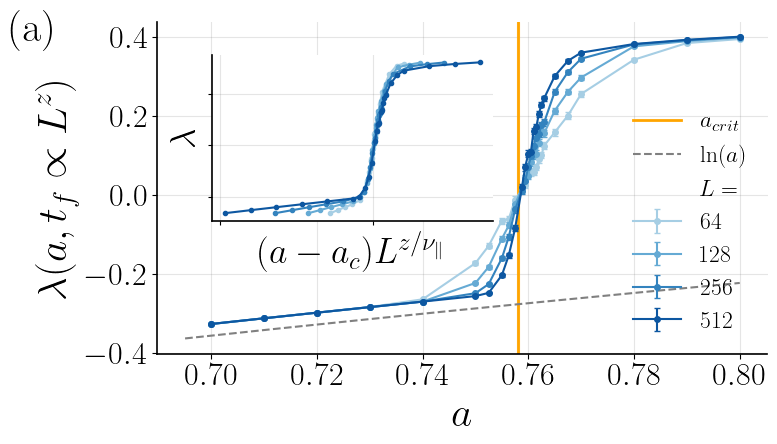

In [49]:
a_crit, a_crit_err = 0.7585, 0.001
a_crit, a_crit_err = 0.758, 0.0002
nu_par, nu_par_err = 2.24, 0.05
z_collapse = 1.34
nu = nu_par / z_collapse

for averaging_window in averaging_windows:
    aw_name = str(round(averaging_window, 3)).replace(".", "p")

    fig, ax = plt.subplots(figsize=(8, 5))

    x_range = np.linspace(min(a_vals) - 0.005, max(a_vals) + 0.00005, 1000)
    ax.axvspan(a_crit - a_crit_err, a_crit + a_crit_err, color="orange", alpha=0.2)
    ax.axvline(a_crit, color="orange", lw=2, label=r"$a_{crit}$")
    ax.plot(x_range, np.log(x_range), linestyle="--", color="gray", label=r"$\ln(a)$")

    plt.plot([], [], label=r"$L=$", c=(1, 1, 1, 0))

    L_vals = [n * N_val for n in num_unit_cells_vals]
    for i, L in enumerate(L_vals):
        lam_dict = collected_lambdas[averaging_window][L]
        sem_dict = collected_lambdas_SEMs[averaging_window][L]
        xs = sorted(lam_dict.keys())
        ys = [lam_dict[a] for a in xs]
        yerr = [sem_dict[a] for a in xs]
        ax.errorbar(
            xs, ys, yerr=yerr,
            marker="o", markersize=4, label=str(L), color=blue_colors[i], capsize=2
        )

    ax.set_xlabel(r"$a$")
    ax.set_ylabel(rf"$\lambda(a, t_f \propto L^z)$")
    ax.text(0.01, 0.855, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    ax.legend(loc="lower right", fontsize=plt.rcParams["legend.fontsize"] - 4)

    # --- Inset (FSS / collapsed plot) ---
    ax_inset = ax.inset_axes([0.09, 0.4, 0.46, 0.5])  # adjust to taste

    for i, L in enumerate(L_vals):
        lam_dict = collected_lambdas[averaging_window][L]
        sem_dict = collected_lambdas_SEMs[averaging_window][L]
        xs = np.array(sorted(lam_dict.keys()))
        ys = [lam_dict[a] for a in xs]
        yerr = [sem_dict[a] for a in xs]
        ax_inset.errorbar(
            (xs - a_crit) * L ** (z_collapse / nu_par), ys, yerr=yerr,
            marker="o", markersize=3, color=blue_colors[i], capsize=1.5
        )

    ax_inset.set_xlabel(r"$(a-a_c)L^{z/\nu_{\|}}$", fontsize=plt.rcParams["axes.labelsize"] - 4)
    ax_inset.set_ylabel(rf"$\lambda$", fontsize=plt.rcParams["axes.labelsize"] - 4)
    ax_inset.tick_params(labelbottom=False, labelleft=False, length=3)
    # ---

    plot_path = (
        f"figs/lambda_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
        f"fss_lambda_per_a_N{N_val}_AW{aw_name}_z{z_fit_name}_inset.png"
    )
    make_path_exist(plot_path)
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150)
    print(f"Saved: {plot_path}")
    plt.show()

## Plot 2 — Std(λ) vs *a* per Averaging Window (all L together)

Saved: figs/lambda_per_a/N4/SeveralAs/IC1000/SeveralLs/stds_lambda_per_a_N4_AW0p5_z1p34_Stds.png


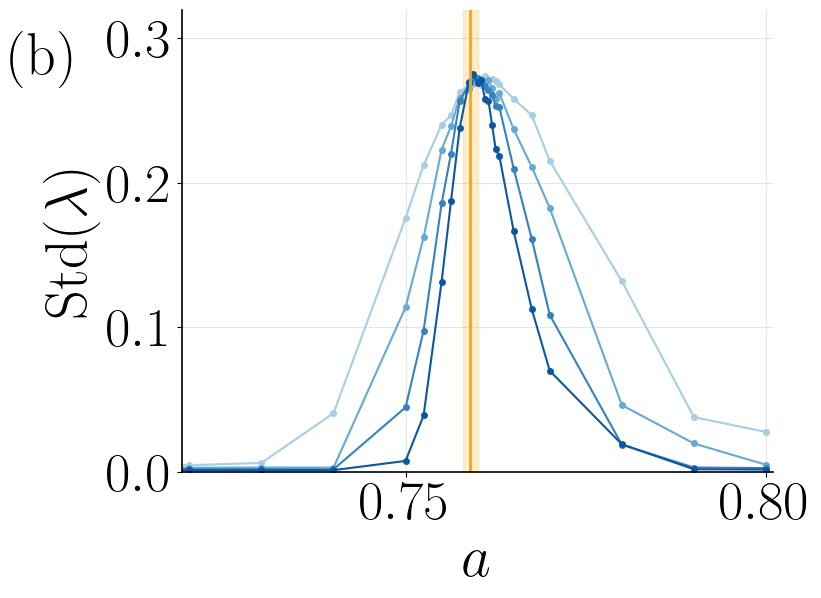

In [79]:
a_crit, a_crit_err = 0.759, 0.001
for aw in averaging_windows:
    aw_name = str(aw).replace(".", "p")
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xlim(0.719, 0.801)
    ax.set_ylim(0, 0.32)
    ax.set_xlabel(r"$a$")
    ax.set_ylabel(r"$\mathrm{Std}(\lambda)$")
    # ax.set_title(rf"$\mathrm{{Std}}(\lambda(a))$ for $N={N_val}$, $AW={round(aw, 6)}$, $z_f={z_fit}$")
    
    for i, L in enumerate([n * N_val for n in num_unit_cells_vals]):
        sem_dict = collected_lambdas_SEMs[aw][L]
        xs = sorted(sem_dict.keys())
        ys = [sem_dict[a] * np.sqrt(num_initial_conds - 1) for a in xs]
        ax.plot(xs, ys, marker="o", markersize=4, label=str(L), color=blue_colors[i])

    ax.text(0.03, 0.82, "(b)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    
    ax.axvline(a_crit, color="orange", lw=2, label=r"$a_{crit}$")
    ax.axvspan(a_crit-a_crit_err, a_crit+a_crit_err, color="orange", alpha=0.2)
    # ax.legend(title="L =")
    out_path = (
        f"figs/lambda_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
        f"stds_lambda_per_a_N{N_val}_AW{aw_name}_z{z_fit_name}_Stds.png"
    )
    make_path_exist(out_path)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    print(f"Saved: {out_path}")
    plt.show()

## Plot 5 — Finite-Size Scaling (FSS) Collapse of Std(λ)

  Skipping L=32: not in loaded data
Saved: figs/lambda_per_a/N4/SeveralAs/IC1000/SeveralLs/collapsed_stds_lambda_N4_AW0p5_z1p34_Stds_Collapsed.png


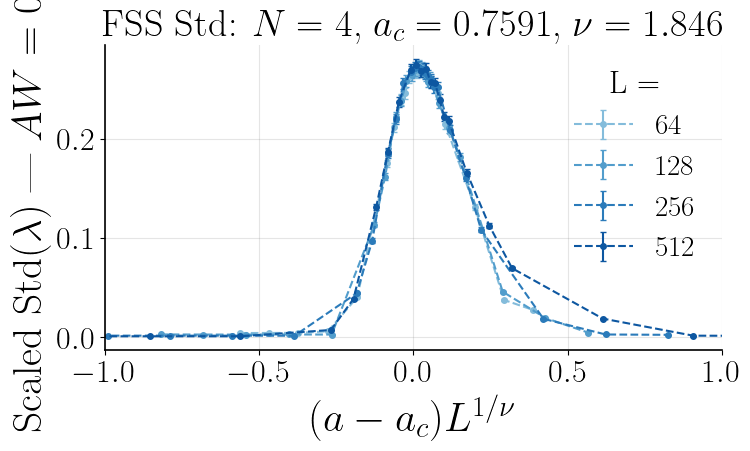

In [6]:
num_unit_cells_vals_fss = [8, 16, 32, 64, 128]

a_crit, a_crit_err = 0.7591, 0.0002
nu_par, nu_par_err         = 2.4, 0.05
z_collapse = 1.3
nu = nu_par/z_collapse

for averaging_window in averaging_windows:
    aw_name = str(round(averaging_window, 3)).replace(".", "p")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_xlim(-1, 1)
    ax.set_xlabel(r"$(a - a_c) L^{1/\nu}$")
    ax.set_ylabel(rf"Scaled $\mathrm{{Std}}(\lambda)$ | $AW={averaging_window}$")
    ax.set_title(rf"FSS Std: $N={N_val}$, $a_c={round(a_crit,4)}$, $\nu={round(nu,3)}$")

    fss_colors = [mcolors.to_rgba(c) for c in
                plt.cm.Blues(np.linspace(0.3, 0.85, len(num_unit_cells_vals_fss)))]

    for i, nuc in enumerate(num_unit_cells_vals_fss):
        L = nuc * N_val
        if L not in collected_lambdas_SEMs[averaging_window]:
            print(f"  Skipping L={L}: not in loaded data")
            continue
        sem_dict = collected_lambdas_SEMs[averaging_window][L]
        xs_raw   = sorted(sem_dict.keys())
        xs_scaled = [(a - a_crit) * L ** (1 / nu) for a in xs_raw]
        ys        = np.array([sem_dict[a] * np.sqrt(num_initial_conds - 1) for a in xs_raw])
        yerr      = np.array([sem_dict[a] / np.sqrt(2) for a in xs_raw])
        ax.errorbar(xs_scaled, ys, yerr=yerr, marker="o", markersize=4,
                    linestyle="--", label=str(L), color=fss_colors[i], capsize=2)

    ax.legend(title="L =")
    collapsed_path = (
        f"figs/lambda_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
        f"collapsed_stds_lambda_N{N_val}_AW{aw_name}_z{z_fit_name}_Stds_Collapsed.png"
    )
    make_path_exist(collapsed_path)
    fig.tight_layout()
    fig.savefig(collapsed_path, dpi=150)
    print(f"Saved: {collapsed_path}")
    plt.show()

## Plot 8 — Publication Figure: Std(λ) with FSS Inset


Saved: figs/lambda_per_a/N4/SeveralAs/IC1000/SeveralLs/stds_with_inset.png


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36871/3568016852.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


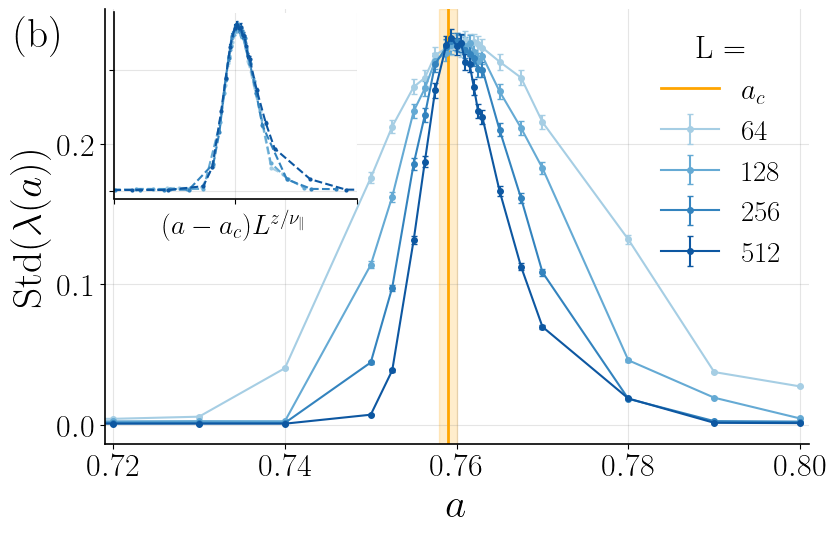

In [ ]:
for averaging_window in averaging_windows:
    a_crit, a_crit_err = 0.759, 0.001

    fig, ax_main = plt.subplots(figsize=(9, 6))
    ax_main.set_xlim(0.719, 0.801)
    ax_main.set_xlabel(r"$a$")
    ax_main.set_ylabel(r"$\mathrm{Std}(\lambda(a))$")
    # ax_main.set_title(rf"$AW={averaging_window}$, $z_f={z_fit}$, $z_{{collapse}}={1.3}$,  $\nu_{{\|}} = 2.4$")
    ax_main.text(0.06, 0.855, "(b)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    # ax_main.text(-0.12, 1.02, "(b)", transform=ax_main.transAxes, fontsize=20, va="top", ha="left")

    for i, L in enumerate([n * N_val for n in num_unit_cells_vals]):
        sem_dict = collected_lambdas_SEMs[averaging_window][L]
        xs   = sorted(sem_dict.keys())
        ys   = np.array([sem_dict[a] * np.sqrt(num_initial_conds - 1) for a in xs])
        yerr = np.array([sem_dict[a] / np.sqrt(2) for a in xs])
        ax_main.errorbar(xs, ys, yerr=yerr, marker="o", markersize=4,
                        label=str(L), color=blue_colors[i], capsize=2)

    ax_main.axvspan(a_crit - a_crit_err, a_crit + a_crit_err, color="orange", alpha=0.2)
    ax_main.axvline(a_crit, color="orange", lw=2, label=r"$a_c$")
    ax_main.legend(title="L =", loc="upper right")

    # Inset — FSS collapse
    inset_rect = [0.17, 0.6, 0.27, 0.31]
    ax_inset = fig.add_axes(inset_rect)
    ax_inset.set_xlim(-1, 1)
    ax_inset.set_xlabel(r"$(a-a_c)L^{z/\nu_{\|}}$", fontsize=20)
    ax_inset.tick_params(labelleft=False, labelbottom=False)

    for i, L in enumerate([n * N_val for n in num_unit_cells_vals]):
        sem_dict  = collected_lambdas_SEMs[averaging_window][L]
        xs_raw    = sorted(sem_dict.keys())
        xs_scaled = [(a - a_crit) * L ** (1 / nu) for a in xs_raw]
        ys        = np.array([sem_dict[a] * np.sqrt(num_initial_conds - 1) for a in xs_raw])
        yerr      = np.array([sem_dict[a] / np.sqrt(2) for a in xs_raw])
        ax_inset.errorbar(xs_scaled, ys, yerr=yerr, marker="o", markersize=2,
                        linestyle="--", color=blue_colors[i], capsize=1)

    inset_path = (
        f"figs/lambda_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/stds_with_inset.png"
    )
    plt.tight_layout()
    make_path_exist(inset_path)
    fig.savefig(inset_path, dpi=150)
    print(f"Saved: {inset_path}")
    plt.show()

Saved: figs/lambda_per_a/N4/SeveralAs/IC1000/SeveralLs/lambda_per_a_N4_AW0p333_z1p34_with_std.png


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_11785/1757815636.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


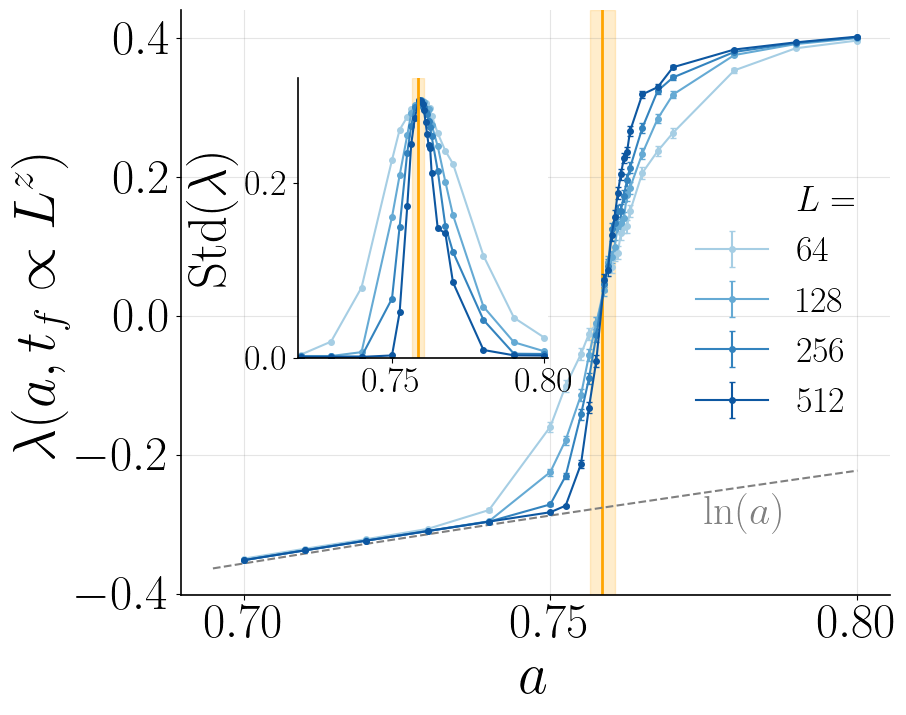

In [50]:
a_crit, a_crit_err = 0.7585, 0.002

plt.rcParams["font.size"] = 35
plt.rcParams["axes.labelsize"] = 42
plt.rcParams["legend.fontsize"] = 30

for averaging_window in averaging_windows:
    aw_name = str(round(averaging_window, 3)).replace(".", "p")

    fig, ax = plt.subplots(figsize=(10, 8))
    # ax.set_xlim(0.695, 0.8025)
    # ax.text(-0.19, 1.01, "(a)", transform=ax.transAxes, fontsize=20, va="top", ha="left")


    x_range = np.linspace(min(a_vals) - 0.005, max(a_vals) + 0.00005, 1000)
    ax.axvspan(a_crit - a_crit_err, a_crit + a_crit_err, color="orange", alpha=0.2)
    ax.axvline(a_crit, color="orange", lw=2)
    ax.plot(x_range, np.log(x_range), linestyle="--", color="gray")
    ax.text(0.775, -0.3, r"$\ln(a)$", fontsize=plt.rcParams["axes.labelsize"]-12, c="grey")

    plt.plot([], [], label=r"$L=$", c=(1, 1, 1, 0))

    L_vals = [n * N_val for n in num_unit_cells_vals]
    for i, L in enumerate(L_vals):
        lam_dict = collected_lambdas[averaging_window][L]
        sem_dict = collected_lambdas_SEMs[averaging_window][L]
        xs = sorted(lam_dict.keys())
        ys = [lam_dict[a] for a in xs]
        yerr = [sem_dict[a] for a in xs]
        ax.errorbar(xs, ys, yerr=yerr, marker="o", markersize=4,
                    label=str(L), color=blue_colors[i], capsize=2)


    ax.set_xlabel(r"$a$")
    ax.set_ylabel(rf"$\lambda(a, t_f \propto L^z)$")
    # ax.set_title(rf"$\lambda(t=L^{{{z_fit}}}, a)$ for $N={N_val}$, $AW={averaging_window}$")
    # ax.text(0.05, 0.85, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)

    # inset
    # a_crit, a_crit_err = 0.759, 0.001
    inset_rect = [0.34, 0.5, 0.25, 0.35]
    ax_inset = fig.add_axes(inset_rect)
    ax_inset.tick_params(labelleft=True, labelbottom=True, labelsize=26)
    ax_inset.set_xlim(0.719, 0.801)
    ax_inset.set_ylim(0, 0.32)
    ax_inset.grid(False)
    # ax_inset.set_xlabel(r"$a$")
    ax_inset.set_ylabel(r"$\mathrm{Std}(\lambda)$", fontsize=38)
    # ax.set_title(rf"$\mathrm{{Std}}(\lambda(a))$ for $N={N_val}$, $AW={round(aw, 6)}$, $z_f={z_fit}$")
    
    for i, L in enumerate([n * N_val for n in num_unit_cells_vals]):
        sem_dict = collected_lambdas_SEMs[averaging_window][L]
        xs = sorted(sem_dict.keys())
        ys = [sem_dict[a] * np.sqrt(num_initial_conds - 1) for a in xs]
        ax_inset.plot(xs, ys, marker="o", markersize=4, label=str(L), color=blue_colors[i])

    # ax_inset.text(0.03, 0.82, "(b)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    
    ax_inset.axvline(a_crit, color="orange", lw=2, label=r"$a_{crit}$")
    ax_inset.axvspan(a_crit-a_crit_err, a_crit+a_crit_err, color="orange", alpha=0.2)
    
    ax.legend(loc="center right",fontsize=plt.rcParams["legend.fontsize"]-4)

    plot_path = (
        f"figs/lambda_per_a/N{N_val}/SeveralAs/IC{num_initial_conds}/SeveralLs/"
        f"lambda_per_a_N{N_val}_AW{aw_name}_z{z_fit_name}_with_std.png"
    )
    make_path_exist(plot_path)
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150)
    print(f"Saved: {plot_path}")
    plt.show()